<a href="https://colab.research.google.com/github/germfsip/Agentes-Inteligentes-2026/blob/main/Unir_AI_Sesion5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/germfsip/Agentes-Inteligentes-2026/blob/main/Unir_AI_Sesion5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 5 — Recurrent Neural Networks (RNN)

**Asignatura:** Sistemas Cognitivos Artificiales — Maestría UNIR México  
**Profesor:** Gerardo A. Martínez Fernández  
**Tema 7:** Recurrent Neural Networks (RNN)

---

## Objetivos de esta práctica

1. Implementar una Vanilla RNN from scratch con NumPy para entender la recurrencia
2. Entrenar un modelo de lenguaje char-level con PyTorch `nn.RNN`
3. Construir un clasificador de sentimiento con LSTM
4. Comparar LSTM vs GRU en la misma tarea
5. Explorar arquitecturas Stacked y Bidirectional

## Parte 1: Setup e imports

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Reproducibilidad
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
print(f'PyTorch: {torch.__version__}')

Dispositivo: cpu
PyTorch: 2.11.0+cpu


## Parte 2: Vanilla RNN Forward Pass (from scratch)

Implementamos la fórmula de recurrencia con NumPy puro:

$$h_t = \tanh(W_{hh} \cdot h_{t-1} + W_{xh} \cdot x_t + b)$$
$$y_t = W_{hy} \cdot h_t$$

Esto corresponde a las ecuaciones del Tema 7.2 del material UNIR.

In [2]:
class VanillaRNN:
    """Vanilla RNN implementada from scratch con NumPy."""
    def __init__(self, input_size, hidden_size, output_size):
        # Inicializar pesos (Xavier initialization)
        scale_xh = np.sqrt(2.0 / (input_size + hidden_size))
        scale_hh = np.sqrt(2.0 / (hidden_size + hidden_size))
        scale_hy = np.sqrt(2.0 / (hidden_size + output_size))
        self.W_xh = np.random.randn(hidden_size, input_size) * scale_xh
        self.W_hh = np.random.randn(hidden_size, hidden_size) * scale_hh
        self.W_hy = np.random.randn(output_size, hidden_size) * scale_hy
        self.b_h = np.zeros((hidden_size, 1))
        self.b_y = np.zeros((output_size, 1))
        self.hidden_size = hidden_size

    def forward(self, inputs, h_prev=None):
        """Forward pass sobre una secuencia de inputs."""
        if h_prev is None:
            h_prev = np.zeros((self.hidden_size, 1))
        hidden_states = [h_prev]
        outputs = []
        for x_t in inputs:
            h_t = np.tanh(
                self.W_hh @ hidden_states[-1] +
                self.W_xh @ x_t +
                self.b_h
            )
            y_t = self.W_hy @ h_t + self.b_y
            hidden_states.append(h_t)
            outputs.append(y_t)
        return outputs, hidden_states[1:]

print('✓ Clase VanillaRNN definida')

✓ Clase VanillaRNN definida


### Ejemplo: secuencia "hello"
Vocabulario `[h, e, l, o]`, representación one-hot, predicción del siguiente carácter.

In [3]:
# Vocabulario y encoding
vocab = ['h', 'e', 'l', 'o']
char_to_idx = {c: i for i, c in enumerate(vocab)}
vocab_size = len(vocab)

def one_hot(char):
    """Crear vector one-hot para un carácter."""
    v = np.zeros((vocab_size, 1))
    v[char_to_idx[char]] = 1.0
    return v

# Secuencia: "hell" → targets: "ello"
input_chars = list('hell')
target_chars = list('ello')
inputs = [one_hot(c) for c in input_chars]
targets = [char_to_idx[c] for c in target_chars]

print(f'Vocabulario: {vocab}')
print('Input:  ' + ''.join(input_chars) + f' → one-hot de dimensión {vocab_size}')
print('Target: ' + ''.join(target_chars) + f' → índices {targets}')

# Forward pass
rnn = VanillaRNN(input_size=vocab_size, hidden_size=5, output_size=vocab_size)
outputs, hidden_states = rnn.forward(inputs)

# Resultados por time step
print(f'\n📊 Forward pass (pesos aleatorios, sin entrenar):')
print('=' * 55)
for t, (inp_c, tgt_c, y_t, h_t) in enumerate(
    zip(input_chars, target_chars, outputs, hidden_states)):
    exp_y = np.exp(y_t - np.max(y_t))
    probs = exp_y / exp_y.sum()
    pred_idx = np.argmax(probs)
    pred_char = vocab[pred_idx]
    print(f'  t={t}: input=\'{inp_c}\' → pred=\'{pred_char}\' '
          f'(target=\'{tgt_c}\') | h_t norm={np.linalg.norm(h_t):.3f}')

print()
print('Las predicciones son aleatorias porque los pesos no están entrenados.')
print('Con BPTT (backpropagation through time), la red aprendería a predecir "ello".')

Vocabulario: ['h', 'e', 'l', 'o']
Input:  hell → one-hot de dimensión 4
Target: ello → índices [1, 2, 2, 3]

📊 Forward pass (pesos aleatorios, sin entrenar):
  t=0: input='h' → pred='h' (target='e') | h_t norm=0.568
  t=1: input='e' → pred='o' (target='l') | h_t norm=0.893
  t=2: input='l' → pred='h' (target='l') | h_t norm=1.155
  t=3: input='l' → pred='o' (target='o') | h_t norm=1.260

Las predicciones son aleatorias porque los pesos no están entrenados.
Con BPTT (backpropagation through time), la red aprendería a predecir "ello".


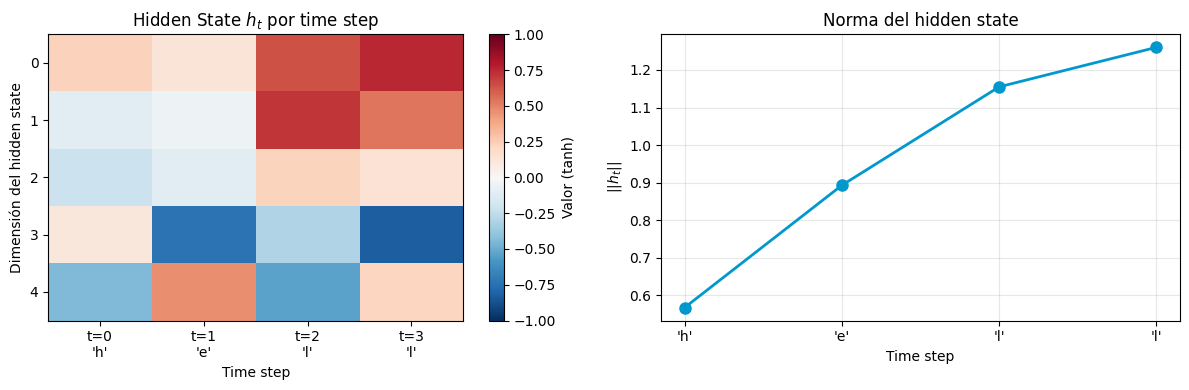

✓ El hidden state codifica la "memoria" de la secuencia vista hasta ahora


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Hidden states como heatmap
h_matrix = np.hstack(hidden_states)
im = axes[0].imshow(h_matrix, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('Dimensión del hidden state')
axes[0].set_xticks(range(len(input_chars)))
axes[0].set_xticklabels([f't={t}\n\'{c}\'' for t, c in enumerate(input_chars)])
axes[0].set_title('Hidden State $h_t$ por time step')
plt.colorbar(im, ax=axes[0], label='Valor (tanh)')

# Norma del hidden state
norms = [np.linalg.norm(h) for h in hidden_states]
axes[1].plot(range(len(norms)), norms, 'o-', color='#0098CD', linewidth=2, markersize=8)
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('||$h_t$||')
axes[1].set_title('Norma del hidden state')
axes[1].set_xticks(range(len(input_chars)))
axes[1].set_xticklabels([f'\'{c}\'' for c in input_chars])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('✓ El hidden state codifica la "memoria" de la secuencia vista hasta ahora')

## Parte 3: Modelo de lenguaje char-level

Entrenamos una RNN con PyTorch para predecir el siguiente carácter (Tema 7.3).
Usamos un texto corto para que el entrenamiento sea rápido en Colab.

In [5]:
# Texto de entrenamiento
text = """Las redes neuronales recurrentes son un tipo de red neuronal que es capaz
de trabajar con informacion secuencial manteniendo un estado interno para procesar
secuencias de entrada. Este tipo de arquitectura aplica una formula recurrente sobre
una secuencia de entrada de manera que en cada paso dado en la secuencia se depende
del nuevo valor de input y del estado interno anterior. Las RNN son muy dinamicas y
pueden tratar una gran variedad de problemas de manera natural. Un modelo del lenguaje
es un modelo que asigna una probabilidad a una secuencia de palabras o caracteres.
Las LSTM surgieron como una arquitectura encaminada a solucionar los problemas de
memoria de las vanilla RNN. La arquitectura GRU fue introducida como alternativa
mas simple con rendimiento comparable a las LSTM."""

# Construir vocabulario
chars = sorted(set(text))
vocab_size = len(chars)
char_to_ix = {c: i for i, c in enumerate(chars)}
ix_to_char = {i: c for i, c in enumerate(chars)}

print(f'Texto: {len(text)} caracteres')
print(f'Vocabulario: {vocab_size} caracteres únicos')
print(f'Primeros 10: {chars[:10]}')

Texto: 792 caracteres
Vocabulario: 34 caracteres únicos
Primeros 10: ['\n', ' ', '.', 'E', 'G', 'L', 'M', 'N', 'R', 'S']


In [6]:
# Preparar secuencias de entrenamiento
seq_length = 30

encoded = [char_to_ix[c] for c in text]
X_seqs, Y_seqs = [], []
for i in range(0, len(encoded) - seq_length, 1):
    X_seqs.append(encoded[i:i+seq_length])
    Y_seqs.append(encoded[i+1:i+seq_length+1])

X = torch.tensor(X_seqs, dtype=torch.long)
Y = torch.tensor(Y_seqs, dtype=torch.long)

print(f'Secuencias de entrenamiento: {X.shape[0]} de longitud {seq_length}')
dataset = TensorDataset(X, Y)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

Secuencias de entrenamiento: 762 de longitud 30


In [7]:
class CharRNN(nn.Module):
    """Modelo de lenguaje char-level con RNN de PyTorch."""
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.RNN(embed_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.hidden_size = hidden_size
        self.num_layers = num_layers

    def forward(self, x, h=None):
        emb = self.embedding(x)
        out, h = self.rnn(emb, h)
        logits = self.fc(out)
        return logits, h

model = CharRNN(vocab_size, embed_size=32, hidden_size=128, num_layers=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.003)
criterion = nn.CrossEntropyLoss()

print(f'📊 Modelo CharRNN:')
print(f'  Parámetros: {sum(p.numel() for p in model.parameters()):,}')
print(f'  Embedding: {vocab_size} → 32')
print(f'  RNN hidden: 128')

📊 Modelo CharRNN:
  Parámetros: 26,210
  Embedding: 34 → 32
  RNN hidden: 128


  Epoch  20/100 — loss: 0.1987
  Epoch  40/100 — loss: 0.1575
  Epoch  60/100 — loss: 0.1459
  Epoch  80/100 — loss: 0.1417
  Epoch 100/100 — loss: 0.1382


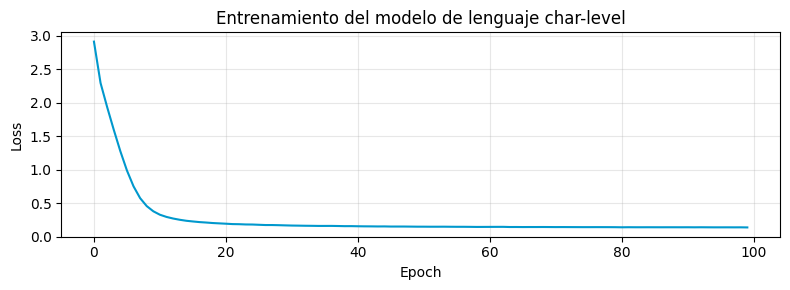

In [8]:
# Entrenamiento
num_epochs = 100
losses = []

for epoch in range(num_epochs):
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits, _ = model(xb)
        loss = criterion(logits.view(-1, vocab_size), yb.view(-1))
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item()
    avg = total_loss / len(loader)
    losses.append(avg)
    if (epoch + 1) % 20 == 0:
        print(f'  Epoch {epoch+1:3d}/{num_epochs} — loss: {avg:.4f}')

plt.figure(figsize=(8, 3))
plt.plot(losses, color='#0098CD', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Entrenamiento del modelo de lenguaje char-level')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Generación de texto
Usamos la RNN entrenada como **modelo generativo**: dada una semilla, predecimos el siguiente carácter y lo realimentamos (Tema 7.3).

In [9]:
def generate_text(model, seed, length=200, temperature=0.8):
    """Generar texto carácter por carácter con muestreo."""
    model.eval()
    chars_out = list(seed)
    input_seq = torch.tensor([[char_to_ix[c] for c in seed]], dtype=torch.long).to(device)

    with torch.no_grad():
        logits, h = model(input_seq)
        last_logits = logits[0, -1] / temperature
        probs = torch.softmax(last_logits, dim=0)
        next_idx = torch.multinomial(probs, 1).item()
        chars_out.append(ix_to_char[next_idx])

        for _ in range(length - 1):
            inp = torch.tensor([[next_idx]], dtype=torch.long).to(device)
            logits, h = model(inp, h)
            last_logits = logits[0, -1] / temperature
            probs = torch.softmax(last_logits, dim=0)
            next_idx = torch.multinomial(probs, 1).item()
            chars_out.append(ix_to_char[next_idx])

    return ''.join(chars_out)

# Generar con diferentes semillas
print('📊 Texto generado:\n')
for seed in ["Las redes", "La arquit", "Un modelo"]:
    print(f'Semilla: "{seed}"')
    print(f'  → {generate_text(model, seed, length=120)}')
    print()

print('Con más datos y epochs, la calidad del texto generado mejora.')

📊 Texto generado:

Semilla: "Las redes"
  → Las redes neuronales recurrentes son un tipo de red neuronal que es capaz
de trabajar con informacion secuencial manteniendo un e

Semilla: "La arquit"
  → La arquitectura GRU fue introducida como alternativa
mas simple con rendimiento comparable a las LSTM.
mal que es capaz
de trabaj

Semilla: "Un modelo"
  → Un modelo del lenguaje
es un modelo que asigna una probabilidad a una secuencia de palabras o caracteres.
Las LSTM surgieron como

Con más datos y epochs, la calidad del texto generado mejora.


## Parte 4: Análisis de sentimiento con LSTM

Caso clásico de **secuencia → salida única** (Tema 7.2): leemos una secuencia de palabras con una LSTM y producimos una clasificación binaria (positivo/negativo).

La LSTM resuelve el **vanishing gradients** mediante sus gates (forget, input, output) y su cell state — la "autopista de información" (Tema 7.4).

In [10]:
# Dataset sintético de reseñas
positive_reviews = [
    'esta pelicula es excelente y muy entretenida',
    'me encanto la actuacion y la historia es brillante',
    'una obra maestra del cine con gran direccion',
    'fantastica pelicula con un final sorprendente',
    'muy buena la fotografia y el guion es genial',
    'increible actuacion y una trama muy interesante',
    'la mejor pelicula que he visto este anio',
    'una historia conmovedora y muy bien contada',
    'excelente produccion con actores talentosos',
    'me encanto cada momento de esta pelicula',
    'gran trabajo de direccion y cinematografia',
    'una pelicula que vale la pena ver dos veces',
    'actuaciones brillantes y una historia emotiva',
    'la pelicula supero todas mis expectativas',
    'un clasico moderno con mensajes profundos',
]

negative_reviews = [
    'esta pelicula es terrible y muy aburrida',
    'la peor pelicula que he visto en mucho tiempo',
    'actuaciones pesimas y una historia sin sentido',
    'no me gusto nada la direccion ni el guion',
    'una perdida de tiempo total esta pelicula',
    'muy mala la fotografia y el ritmo es lento',
    'historia predecible y personajes sin carisma',
    'el final es decepcionante y sin coherencia',
    'produccion mediocre con un guion terrible',
    'no la recomiendo a nadie es muy aburrida',
    'la trama no tiene logica y es confusa',
    'pelicula sin gracia ni originalidad alguna',
    'actuaciones falsas y dialogos muy malos',
    'me dormi viendo esta pelicula tan lenta',
    'un desastre total de principio a fin',
]

# Construir vocabulario
all_text = ' '.join(positive_reviews + negative_reviews)
words = sorted(set(all_text.split()))
word_to_ix = {w: i+1 for i, w in enumerate(words)}  # 0 = padding
word_to_ix['<pad>'] = 0
w_vocab_size = len(word_to_ix)

def encode_review(review, max_len=12):
    tokens = [word_to_ix.get(w, 0) for w in review.split()]
    if len(tokens) < max_len:
        tokens = tokens + [0] * (max_len - len(tokens))
    return tokens[:max_len]

max_len = 12
X_pos = [encode_review(r, max_len) for r in positive_reviews]
X_neg = [encode_review(r, max_len) for r in negative_reviews]
X_all = torch.tensor(X_pos + X_neg, dtype=torch.long)
Y_all = torch.tensor([1]*len(X_pos) + [0]*len(X_neg), dtype=torch.float32)

# Shuffle
perm = torch.randperm(len(X_all))
X_all, Y_all = X_all[perm], Y_all[perm]

print(f'📊 Dataset: {len(X_all)} reseñas ({len(X_pos)} pos, {len(X_neg)} neg)')
print(f'   Vocabulario: {w_vocab_size} palabras')
print(f'   Secuencia máx: {max_len} tokens')

📊 Dataset: 30 reseñas (15 pos, 15 neg)
   Vocabulario: 110 palabras
   Secuencia máx: 12 tokens


In [11]:
class SentimentLSTM(nn.Module):
    """LSTM para análisis de sentimiento (secuencia → salida única)."""
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        emb = self.embedding(x)
        out, (h_n, c_n) = self.lstm(emb)
        logit = self.fc(h_n.squeeze(0))
        return self.sigmoid(logit)

lstm_model = SentimentLSTM(w_vocab_size, embed_dim=16, hidden_dim=32).to(device)
optimizer_lstm = optim.Adam(lstm_model.parameters(), lr=0.01)
criterion_bce = nn.BCELoss()

print(f'📊 Modelo LSTM para sentimiento:')
print(f'  Embedding: {w_vocab_size} → 16')
print(f'  LSTM hidden: 32')
print(f'  Parámetros: {sum(p.numel() for p in lstm_model.parameters()):,}')
print()
print('Arquitectura LSTM (Tema 7.4):')
print('  Cell state c_t = f_t ⊙ c_{t-1} + i_t ⊙ g_t')
print('  Hidden state h_t = o_t ⊙ tanh(c_t)')
print('  Gates: f(forget), i(input), o(output) — sigmoid → [0,1]')

📊 Modelo LSTM para sentimiento:
  Embedding: 110 → 16
  LSTM hidden: 32
  Parámetros: 8,193

Arquitectura LSTM (Tema 7.4):
  Cell state c_t = f_t ⊙ c_{t-1} + i_t ⊙ g_t
  Hidden state h_t = o_t ⊙ tanh(c_t)
  Gates: f(forget), i(input), o(output) — sigmoid → [0,1]


In [12]:
# Entrenar LSTM
lstm_losses = []
for epoch in range(200):
    lstm_model.train()
    X_batch = X_all.to(device)
    Y_batch = Y_all.to(device)
    pred = lstm_model(X_batch).squeeze()
    loss = criterion_bce(pred, Y_batch)
    optimizer_lstm.zero_grad()
    loss.backward()
    optimizer_lstm.step()
    lstm_losses.append(loss.item())
    if (epoch + 1) % 50 == 0:
        acc = ((pred > 0.5).float() == Y_batch).float().mean()
        print(f'  Epoch {epoch+1:3d} — loss: {loss.item():.4f} — acc: {acc:.1%}')

# Evaluar
lstm_model.eval()
with torch.no_grad():
    pred = lstm_model(X_all.to(device)).squeeze()
    acc = ((pred > 0.5).float() == Y_all.to(device)).float().mean()
    print(f'\nAccuracy final: {acc:.1%}')

  Epoch  50 — loss: 0.0006 — acc: 100.0%
  Epoch 100 — loss: 0.0003 — acc: 100.0%
  Epoch 150 — loss: 0.0002 — acc: 100.0%
  Epoch 200 — loss: 0.0002 — acc: 100.0%

Accuracy final: 100.0%


In [13]:
# Probar con nuevas reseñas
test_reviews = [
    'una pelicula excelente y muy buena',
    'terrible actuacion y aburrida historia',
    'la mejor historia que he visto',
    'no me gusto nada esta pelicula',
]

lstm_model.eval()
print('📊 Predicciones en reseñas nuevas:')
print('=' * 55)
for review in test_reviews:
    x = torch.tensor([encode_review(review, max_len)], dtype=torch.long).to(device)
    with torch.no_grad():
        prob = lstm_model(x).item()
    sentiment = 'POSITIVO ✓' if prob > 0.5 else 'NEGATIVO ✗'
    print(f"  '{review}'")
    print(f'    → {sentiment} (prob={prob:.3f})')
    print()

📊 Predicciones en reseñas nuevas:
  'una pelicula excelente y muy buena'
    → POSITIVO ✓ (prob=1.000)

  'terrible actuacion y aburrida historia'
    → NEGATIVO ✗ (prob=0.000)

  'la mejor historia que he visto'
    → POSITIVO ✓ (prob=1.000)

  'no me gusto nada esta pelicula'
    → NEGATIVO ✗ (prob=0.000)



## Parte 5: LSTM vs GRU

La GRU (2014) simplifica la LSTM: combina cell state y hidden state, y fusiona forget+input gates en una sola update gate (Tema 7.4).

| | LSTM | GRU |
|---|---|---|
| Estados | $h_t$ + $c_t$ | Solo $h_t$ |
| Gates | 3 (forget, input, output) | 2 (reset, update) |
| Parámetros | Más | Menos |

In [14]:
class SentimentGRU(nn.Module):
    """GRU para análisis de sentimiento — comparar con LSTM."""
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        emb = self.embedding(x)
        out, h_n = self.gru(emb)
        logit = self.fc(h_n.squeeze(0))
        return self.sigmoid(logit)

# Entrenar GRU
gru_model = SentimentGRU(w_vocab_size, embed_dim=16, hidden_dim=32).to(device)
optimizer_gru = optim.Adam(gru_model.parameters(), lr=0.01)

gru_losses = []
for epoch in range(200):
    gru_model.train()
    pred = gru_model(X_all.to(device)).squeeze()
    loss = criterion_bce(pred, Y_all.to(device))
    optimizer_gru.zero_grad()
    loss.backward()
    optimizer_gru.step()
    gru_losses.append(loss.item())

gru_model.eval()
with torch.no_grad():
    pred = gru_model(X_all.to(device)).squeeze()
    gru_acc = ((pred > 0.5).float() == Y_all.to(device)).float().mean()

print(f'📊 Comparación:')
print(f'  LSTM — params: {sum(p.numel() for p in lstm_model.parameters()):,} — acc: {acc:.1%}')
print(f'  GRU  — params: {sum(p.numel() for p in gru_model.parameters()):,} — acc: {gru_acc:.1%}')
print()
print('GRU tiene ~25% menos parámetros que LSTM con rendimiento comparable (Tema 7.4).')

📊 Comparación:
  LSTM — params: 8,193 — acc: 100.0%
  GRU  — params: 6,593 — acc: 100.0%

GRU tiene ~25% menos parámetros que LSTM con rendimiento comparable (Tema 7.4).


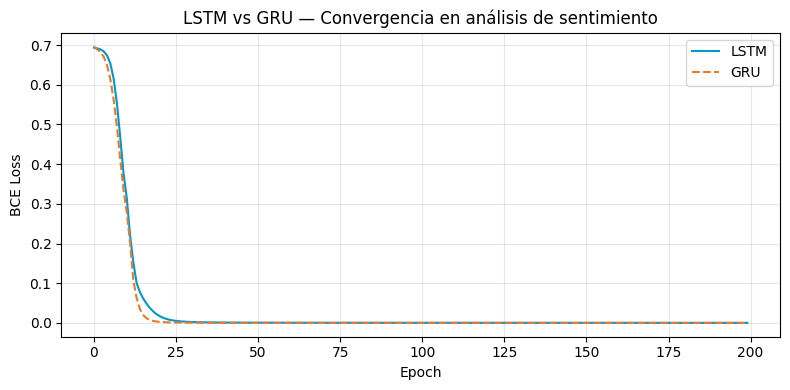

Ambas arquitecturas convergen a soluciones similares.


In [15]:
# Comparar curvas de entrenamiento
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lstm_losses, label='LSTM', color='#0098CD', linewidth=1.5)
ax.plot(gru_losses, label='GRU', color='#E8792F', linewidth=1.5, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('LSTM vs GRU — Convergencia en análisis de sentimiento')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Ambas arquitecturas convergen a soluciones similares.')

## Parte 6: Stacked y Bidirectional RNN

**Stacked:** la salida de una RNN alimenta la siguiente capa apilada (Tema 7.4). Profundidades típicas: 2–5 capas.

**Bidirectional:** lee la secuencia en ambas direcciones. Útil para clasificación (tenemos toda la secuencia), no para generación.

In [16]:
class StackedBiLSTM(nn.Module):
    """LSTM apilada y bidireccional para clasificación."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, bidirectional):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.1 if num_layers > 1 else 0
        )
        fc_input = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(fc_input, 1)
        self.sigmoid = nn.Sigmoid()
        self.bidirectional = bidirectional

    def forward(self, x):
        emb = self.embedding(x)
        out, (h_n, c_n) = self.lstm(emb)
        if self.bidirectional:
            h_cat = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            h_cat = h_n[-1]
        return self.sigmoid(self.fc(h_cat))

# Comparar configuraciones
configs = [
    ('1-layer unidirectional', 1, False),
    ('2-layer stacked', 2, False),
    ('1-layer bidirectional', 1, True),
    ('2-layer stacked + bidirectional', 2, True),
]

results = {}
print('📊 Comparación de arquitecturas RNN:\n')
for name, num_layers, bidir in configs:
    model_cfg = StackedBiLSTM(w_vocab_size, 16, 32, num_layers, bidir).to(device)
    opt = optim.Adam(model_cfg.parameters(), lr=0.01)
    for epoch in range(200):
        model_cfg.train()
        pred = model_cfg(X_all.to(device)).squeeze()
        loss = criterion_bce(pred, Y_all.to(device))
        opt.zero_grad()
        loss.backward()
        opt.step()
    model_cfg.eval()
    with torch.no_grad():
        pred = model_cfg(X_all.to(device)).squeeze()
        acc_cfg = ((pred > 0.5).float() == Y_all.to(device)).float().mean().item()
    n_params = sum(p.numel() for p in model_cfg.parameters())
    results[name] = (acc_cfg, n_params)
    print(f'  {name:40s} — params: {n_params:6,} — acc: {acc_cfg:.1%}')

print()
print('En un dataset pequeño todas convergen rápido.')
print('La ventaja de stacked/bidirectional se ve en datasets grandes.')

📊 Comparación de arquitecturas RNN:

  1-layer unidirectional                   — params:  8,193 — acc: 100.0%
  2-layer stacked                          — params: 16,641 — acc: 100.0%
  1-layer bidirectional                    — params: 14,625 — acc: 100.0%
  2-layer stacked + bidirectional          — params: 39,713 — acc: 100.0%

En un dataset pequeño todas convergen rápido.
La ventaja de stacked/bidirectional se ve en datasets grandes.


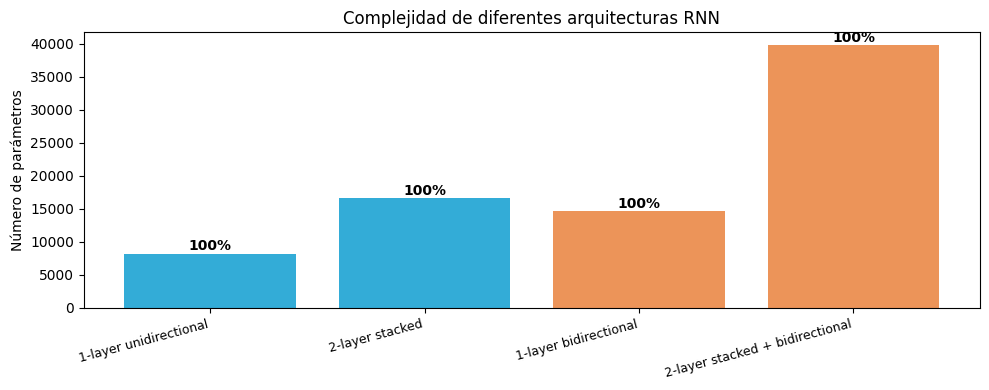

In [17]:
# Visualizar complejidad
fig, ax = plt.subplots(figsize=(10, 4))
names = list(results.keys())
params = [results[n][1] for n in names]
accs = [results[n][0] * 100 for n in names]

x = range(len(names))
bars = ax.bar(x, params, color=['#0098CD', '#0098CD', '#E8792F', '#E8792F'], alpha=0.8)
ax.set_ylabel('Número de parámetros')
ax.set_title('Complejidad de diferentes arquitecturas RNN')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)

for i, (bar, acc) in enumerate(zip(bars, accs)):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
            f'{acc:.0f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## Resumen

| Concepto | Fórmula clave | Problema que resuelve |
|----------|---------------|----------------------|
| **Vanilla RNN** | $h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t)$ | Procesamiento secuencial básico |
| **BPTT** | Backprop "desenrollado" en el tiempo | Entrenar RNNs |
| **LSTM** | 3 gates (f, i, o) + cell state $c_t$ | Vanishing gradients, memoria largo plazo |
| **GRU** | 2 gates (reset, update) | Versión más simple de LSTM |
| **Stacked** | Salida capa $k$ → entrada capa $k+1$ | Representaciones más profundas |
| **Bidirectional** | Forward + backward → concatenar | Contexto completo de la secuencia |

## Ejercicios propuestos

1. **BPTT manual:** Implementa backpropagation through time sobre la VanillaRNN de la Parte 2. Entrena la red para que realmente aprenda a predecir "ello" a partir de "hell".
2. **Dropout en LSTM:** Agrega `dropout=0.3` al modelo de sentimiento. ¿Cómo afecta el entrenamiento con un dataset tan pequeño?
3. **Secuencias más largas:** Modifica el modelo de lenguaje char-level para usar LSTM en vez de RNN. ¿Mejora la calidad del texto generado? Prueba con `seq_length=60`.
4. **Dataset real:** Descarga un dataset de reseñas en español (p.ej. de TASS o MeLi) y entrena el LSTM de sentimiento. ¿Cómo cambia el rendimiento con datos reales vs sintéticos?
5. **Attention preview:** Investiga el mecanismo de atención (Tema 11) y cómo modifica la arquitectura encoder-decoder basada en RNN.

---

**Para profundizar:**
- Stanford CS231N Lecture 10: [RNN](https://www.youtube.com/watch?v=6niqTuYFZLQ)
- Colah's blog: [Understanding LSTMs](http://colah.github.io/posts/2015-08-Understanding-LSTMs/)
- Material UNIR Tema 7 — Ideas clave

---

*Notebook generado para Sistemas Cognitivos Artificiales — UNIR México — Sesión 5*